⏳ Carregando Textos e Profundidade...
⏳ Carregando Tópicos...
⏳ Carregando Notas de Toxicidade...
⏳ Carregando Datas (Raw)...
🔄 Cruzando as bases...
✅ Base pronta para a RQ1! Total de posts raiz (profundidade 0) mapeados: 186389


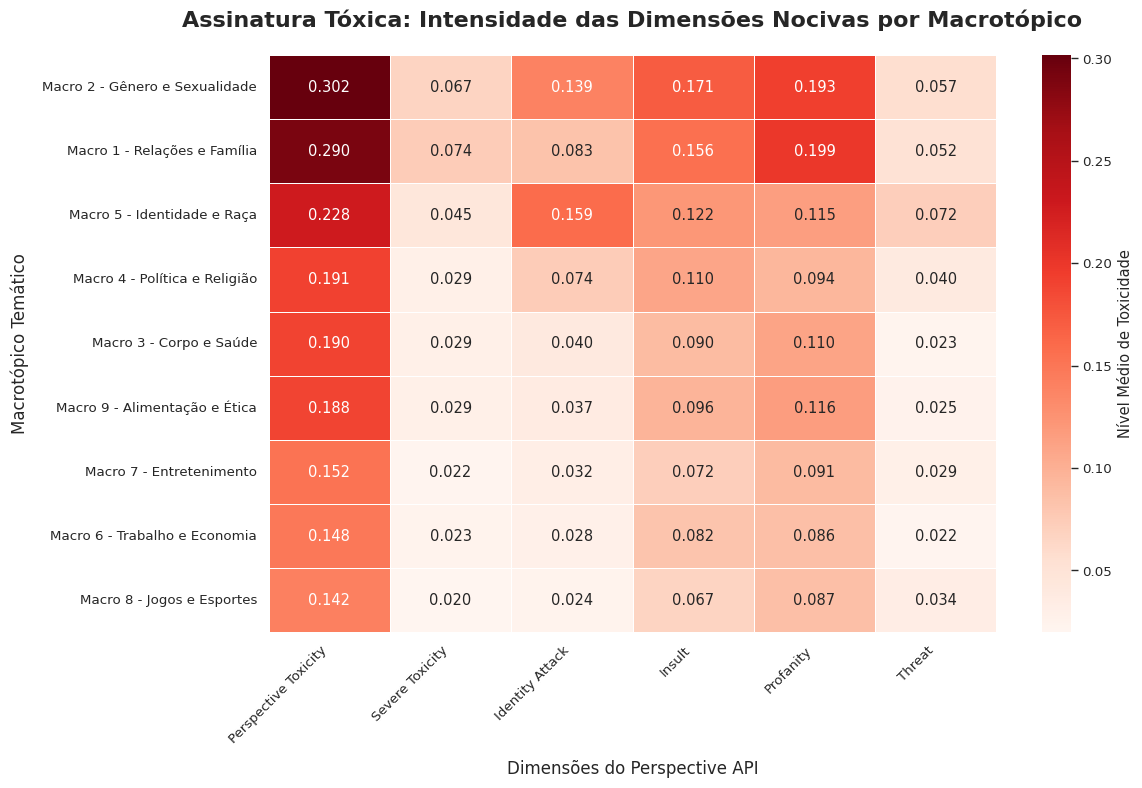

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys

# ==========================================
# 1. CARREGAMENTO DAS BASES
# ==========================================
from src.utils.paths import ROOT

print("⏳ Carregando Textos e Profundidade...")
df_textos = pd.read_parquet(ROOT / "data" / "processed" / "preprocess_text.parquet", columns=['id', 'depth'])

print("⏳ Carregando Tópicos...")
df_topicos = pd.read_parquet(ROOT / "data" / "processed" / "post_topics_1.parquet")

print("⏳ Carregando Notas de Toxicidade...")
df_notas = pd.read_csv(ROOT / "data" / "processed" / "toxicidade_perspective_COMPLETO.csv")

# IMPORTANTE: Carregamento das datas brutas
# Ajuste o caminho/formato de acordo com a sua pasta 'expansao'
print("⏳ Carregando Datas (Raw)...")
caminho_raw = ROOT / "data" / "raw" / "expansao" # Ajuste se for um arquivo específico, ex: "dados.parquet"
# df_datas = pd.read_parquet(caminho_raw, columns=['id', 'created_utc']) 
# Vou criar um df_datas vazio (apenas como placeholder) para o código não quebrar. 
# VOCÊ PRECISA DESCOMENTAR A LINHA ACIMA E AJUSTAR O NOME DO ARQUIVO REAL!

# ==========================================
# 2. CRUZAMENTO E FILTRAGEM (Profundidade 0)
# ==========================================
print("🔄 Cruzando as bases...")

# Filtrando APENAS posts originais (depth == 0)
df_textos_root = df_textos[df_textos['depth'] == 0].copy()

# Unindo Textos + Tópicos + Notas
df_rq1 = df_textos_root.merge(df_topicos, on='id', how='inner')
df_rq1 = df_rq1.merge(df_notas, on='id', how='inner')

# Se o df_datas estiver ativo, descomente a linha abaixo para juntar a data também:
# df_rq1 = df_rq1.merge(df_datas, on='id', how='left')

# Removendo nulos do Perspective
df_rq1 = df_rq1.dropna(subset=['perspective_toxicity'])

# ==========================================
# 3. MAPEAMENTO DOS MACROTÓPICOS
# ==========================================
# Dicionário de conversão baseado na sua definição qualitativa
mapa_macros = {
    1: 'Macro 1 - Relações e Família', 4: 'Macro 1 - Relações e Família', 17: 'Macro 1 - Relações e Família',
    9: 'Macro 2 - Gênero e Sexualidade', 15: 'Macro 2 - Gênero e Sexualidade',
    18: 'Macro 3 - Corpo e Saúde', 21: 'Macro 3 - Corpo e Saúde',
    7: 'Macro 4 - Política e Religião', 19: 'Macro 4 - Política e Religião', 20: 'Macro 4 - Política e Religião',
    10: 'Macro 5 - Identidade e Raça', 12: 'Macro 5 - Identidade e Raça',
    11: 'Macro 6 - Trabalho e Economia',
    2: 'Macro 7 - Entretenimento', 5: 'Macro 7 - Entretenimento', 13: 'Macro 7 - Entretenimento',
    6: 'Macro 8 - Jogos e Esportes', 14: 'Macro 8 - Jogos e Esportes',
    16: 'Macro 9 - Alimentação e Ética'
}

# Tópicos 0, 3 e 8 ficam como NaN e serão filtrados
# Assumindo que a coluna do tópico se chama 'Topic' (Ajuste se for 'topic', 'topico', etc.)
coluna_topico = 'topic' # Troque aqui se a coluna do seu parquet tiver outro nome!

df_rq1['Macro_Topic'] = df_rq1[coluna_topico].map(mapa_macros)

# Removendo os tópicos de "Ruído"
df_rq1_valido = df_rq1.dropna(subset=['Macro_Topic']).copy()

print(f"✅ Base pronta para a RQ1! Total de posts raiz (profundidade 0) mapeados: {len(df_rq1_valido)}")

# ==========================================
# 4. GERAÇÃO DO HEATMAP
# ==========================================
# Agrupando pelas médias das métricas por Macrotópico
colunas_toxicidade = ['perspective_toxicity', 'severe_toxicity', 'identity_attack', 'insult', 'profanity', 'threat']
heatmap_data = df_rq1_valido.groupby('Macro_Topic')[colunas_toxicidade].mean()

# Ordenando pelo mais tóxico geral para facilitar a leitura
heatmap_data = heatmap_data.sort_values(by='perspective_toxicity', ascending=False)

# Plotando o Heatmap
sns.set_theme(style="white", context="paper", font_scale=1.1)
plt.figure(figsize=(12, 8))

# Utilizamos o cmap "Reds" para enfatizar o "calor" da toxicidade
ax = sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt=".3f", 
    cmap="Reds", 
    linewidths=.5,
    cbar_kws={'label': 'Nível Médio de Toxicidade'}
)

plt.title('Assinatura Tóxica: Intensidade das Dimensões Nocivas por Macrotópico', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Dimensões do Perspective API', fontsize=12, labelpad=10)
plt.ylabel('Macrotópico Temático', fontsize=12, labelpad=10)

# Melhorando os rótulos do eixo X (removendo os underscores)
ax.set_xticklabels([col.replace('_', ' ').title() for col in colunas_toxicidade], rotation=45, ha='right')

plt.tight_layout()
plt.show()

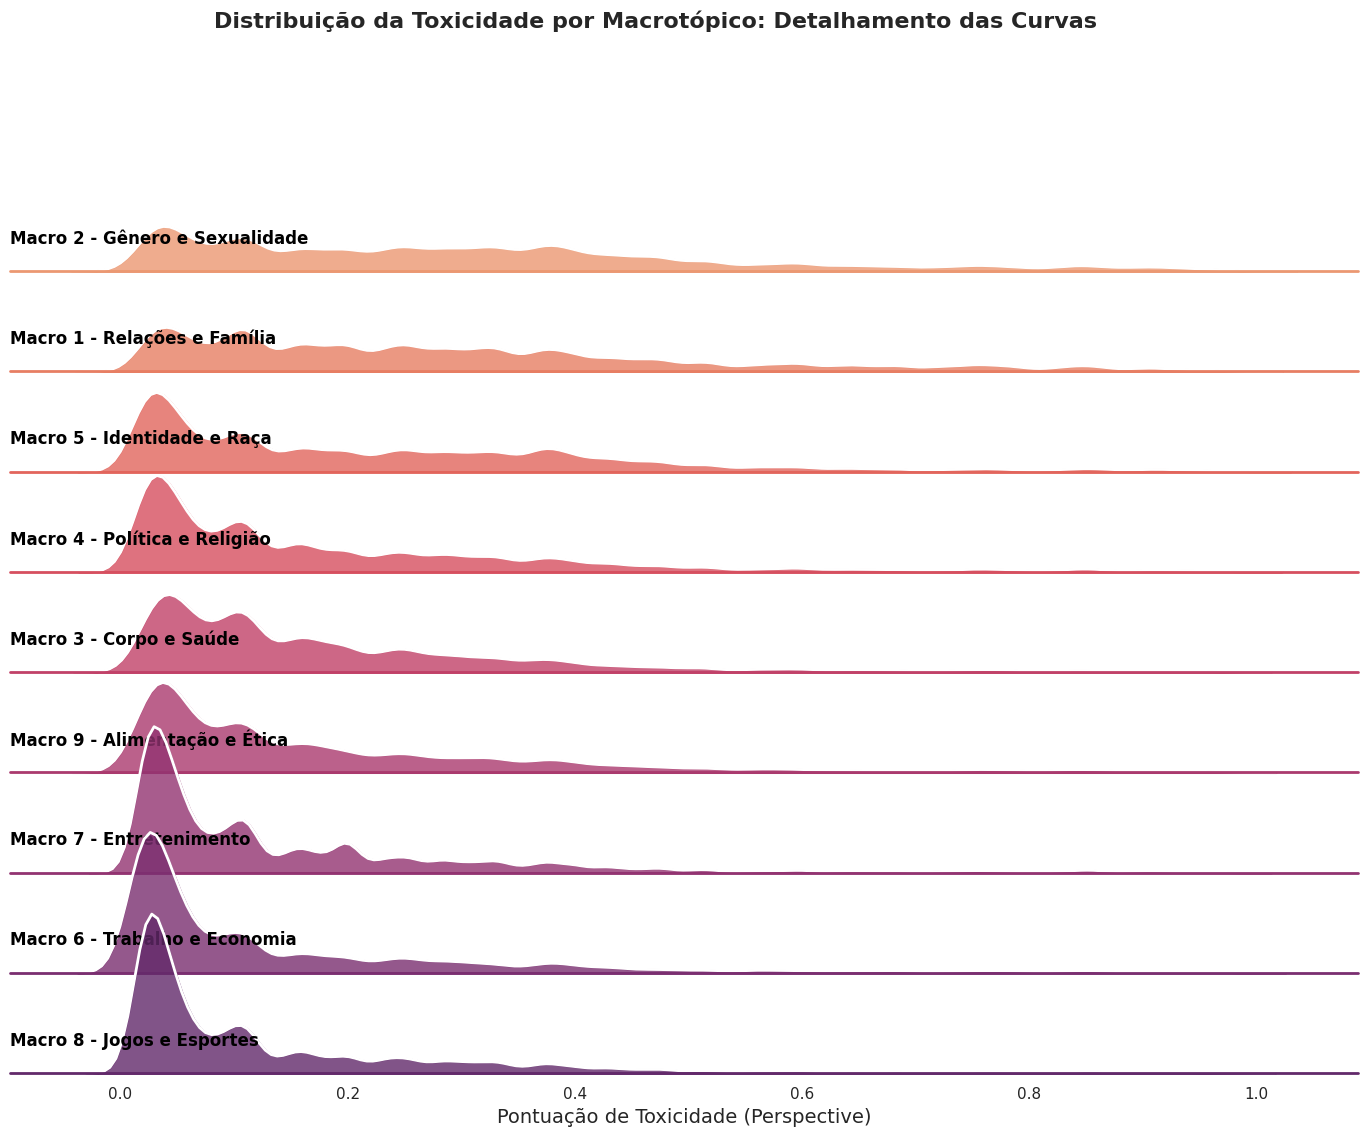

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# RIDGE PLOT (TÍTULOS EM PRETO)
# ==========================================

# Configurando o estilo
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# Ordenando pela média de toxicidade
ordem_macros = df_rq1_valido.groupby('Macro_Topic')['perspective_toxicity'].mean().sort_values(ascending=False).index

# Inicializa o FacetGrid
paleta = sns.color_palette("flare", len(ordem_macros))
g = sns.FacetGrid(
    df_rq1_valido, 
    row="Macro_Topic", 
    row_order=ordem_macros,
    hue="Macro_Topic", 
    hue_order=ordem_macros,
    aspect=12, 
    height=1.2, 
    palette=paleta
)

# Desenha as montanhas (KDE plots)
g.map(sns.kdeplot, "perspective_toxicity", bw_adjust=.5, clip_on=False, fill=True, alpha=0.8, linewidth=1.5)

# Linha branca de contorno
g.map(sns.kdeplot, "perspective_toxicity", clip_on=False, color="w", lw=2, bw_adjust=.5)

# Linha de base horizontal
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

# FUNÇÃO DE RÓTULO ATUALIZADA: Agora forçando a cor preta
def label(x, color, label):
    ax = plt.gca()
    # Mudança aqui: color="black" em vez de color=color
    ax.text(0, .2, label, fontweight="bold", color="black",
            ha="left", va="center", transform=ax.transAxes, fontsize=12)

g.map(label, "perspective_toxicity")

# Ajustes de sobreposição
g.figure.subplots_adjust(hspace=-0.4)
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

# Título e Eixos
plt.suptitle('Distribuição da Toxicidade por Macrotópico: Detalhamento das Curvas', 
             y=1.05, fontsize=16, fontweight='bold')
plt.xlabel('Pontuação de Toxicidade (Perspective)', fontsize=14)

plt.show()

In [6]:
import json
import pandas as pd
from src.utils.paths import ROOT

# Definindo os caminhos exatos que a função exige
DATA_RAW = ROOT / "data" / "raw" / "expansao"
DATA_PROCESSED = ROOT / "data" / "processed"

# Agora você pode colar a função do seu amigo exatamente como está:
def load_raw_data(
    columns=None,
    only_valid_ids=True
):
    """
    Carrega os dados da pasta raw/expansao
    filtra os ids validos
    """
    rows = []

    for depth in range(2):
        dir_path = DATA_RAW / str(depth) / "subreddits"
        if not dir_path.exists():
            continue
        for file_path in dir_path.glob("*.json"):
            try:
                with open(file_path, "r", encoding="utf-8") as f:
                    posts = json.load(f)
                for post in posts:
                    post["depth"] = depth
                rows.extend(posts)
            except json.JSONDecodeError as e:
                print(f"Erro JSON em {file_path}: {e}")

    df = pd.DataFrame(rows)

    if only_valid_ids:
        ids_validos = pd.read_parquet(
            DATA_PROCESSED / "ids_validos.parquet"
        )
        ids = set(ids_validos["id"])
        df = df[df["id"].isin(ids)]

    if columns is not None:
        df = df[columns]
    
    print(f"Posts carregados: {len(df)}")

    return df

In [7]:
# 1. Vamos testar se o Python está a encontrar as tuas pastas corretamente
print(f"🔍 A procurar ficheiros em: {DATA_RAW}")
for d in range(2):
    caminho_teste = DATA_RAW / str(d) / "subreddits"
    if caminho_teste.exists():
        qnt_arquivos = len(list(caminho_teste.glob("*.json")))
        print(f"✅ Pasta {d}/subreddits encontrada com {qnt_arquivos} ficheiros JSON!")
    else:
        print(f"❌ Pasta não encontrada: {caminho_teste}")

print("-" * 50)

# 2. AGORA SIM, ESTAMOS A CHAMAR A FUNÇÃO!
print("⏳ A iniciar a extração de dados brutos...")
df_tempo = load_raw_data(columns=['id', 'timestamp'], only_valid_ids=True)

# 3. Mostrar as primeiras linhas para confirmar que funcionou
if df_tempo is not None and not df_tempo.empty:
    print("\n🎉 Sucesso! Aqui estão as primeiras linhas:")
    display(df_tempo.head())
else:
    print("\n⚠️ A função correu, mas não encontrou dados ou os IDs não coincidiram.")

🔍 A procurar ficheiros em: /home/mateus/reddit/data/raw/expansao
✅ Pasta 0/subreddits encontrada com 1000 ficheiros JSON!
✅ Pasta 1/subreddits encontrada com 6680 ficheiros JSON!
--------------------------------------------------
⏳ A iniciar a extração de dados brutos...
Posts carregados: 1736102

🎉 Sucesso! Aqui estão as primeiras linhas:


,id,timestamp
0,1j3g0q5,2025-03-04T17:20:21+00:00
1,1jdfbt3,2025-03-17T15:26:59+00:00
2,1k7jcux,2025-04-25T12:10:47+00:00
3,1ilwij6,2025-02-10T03:13:42+00:00
4,1jfzx63,2025-03-20T21:17:23+00:00


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from src.utils.paths import ROOT

# ==========================================
# 1. RECONSTRUINDO A BASE REQUERIDA (RÁPIDO)
# ==========================================
print("⏳ Carregando tópicos e notas de toxicidade...")
df_textos = pd.read_parquet(ROOT / "data" / "processed" / "preprocess_text.parquet", columns=['id', 'depth'])
df_topicos = pd.read_parquet(ROOT / "data" / "processed" / "post_topics_1.parquet")
df_notas = pd.read_csv(ROOT / "data" / "processed" / "toxicidade_perspective_COMPLETO.csv")

# Filtrando apenas posts originais (depth == 0)
df_textos_root = df_textos[df_textos['depth'] == 0].copy()

# Unindo as partes
df_rq1 = df_textos_root.merge(df_topicos, on='id', how='inner')
df_rq1 = df_rq1.merge(df_notas, on='id', how='inner')
df_rq1 = df_rq1.dropna(subset=['perspective_toxicity'])

# Detecta automaticamente se a coluna é 'topic' (minúsculo) ou 'Topic' (maiúsculo)
coluna_topico = 'topic' if 'topic' in df_rq1.columns else 'Topic'

# Dicionário de mapeamento dos Macrotópicos
mapa_macros = {
    1: 'Macro 1 - Relações e Família', 4: 'Macro 1 - Relações e Família', 17: 'Macro 1 - Relações e Família',
    9: 'Macro 2 - Gênero e Sexualidade', 15: 'Macro 2 - Gênero e Sexualidade',
    18: 'Macro 3 - Corpo e Saúde', 21: 'Macro 3 - Corpo e Saúde',
    7: 'Macro 4 - Política e Religião', 19: 'Macro 4 - Política e Religião', 20: 'Macro 4 - Política e Religião',
    10: 'Macro 5 - Identidade e Raça', 12: 'Macro 5 - Identidade e Raça',
    11: 'Macro 6 - Trabalho e Economia',
    2: 'Macro 7 - Entretenimento', 5: 'Macro 7 - Entretenimento', 13: 'Macro 7 - Entretenimento',
    6: 'Macro 8 - Jogos e Esportes', 14: 'Macro 8 - Jogos e Esportes',
    16: 'Macro 9 - Alimentação e Ética'
}

df_rq1['Macro_Topic'] = df_rq1[coluna_topico].map(mapa_macros)
df_rq1_valido_local = df_rq1.dropna(subset=['Macro_Topic']).copy()

# ==========================================
# 2. CRUZAMENTO TEMPORAL E TRATAMENTO
# ==========================================
print("🔄 Cruzando as datas com os macrotópicos...")
# Aqui usamos o df_tempo que você acabou de carregar com sucesso!
df_rq1_temporal = df_rq1_valido_local.merge(df_tempo, on='id', how='inner')

print("⏳ Organizando a linha do tempo por meses...")
df_rq1_temporal['data_formatada'] = pd.to_datetime(df_rq1_temporal['timestamp'])
df_rq1_temporal['Ano_Mes'] = df_rq1_temporal['data_formatada'].dt.to_period('M').dt.to_timestamp()

# ==========================================
# 3. PREPARAÇÃO DOS VOLUMES
# ==========================================
print("📊 Calculando os volumes mensais...")
volume_temporal = df_rq1_temporal.groupby(['Ano_Mes', 'Macro_Topic']).size().reset_index(name='Volume')

# Filtrando os 4 principais eixos de toxicidade para o gráfico ficar limpo
macros_foco = [
    'Macro 2 - Gênero e Sexualidade', 
    'Macro 1 - Relações e Família', 
    'Macro 5 - Identidade e Raça',
    'Macro 4 - Política e Religião'
]
volume_filtrado = volume_temporal[volume_temporal['Macro_Topic'].isin(macros_foco)]

# ==========================================
# 4. GERAÇÃO DO GRÁFICO DE LINHAS
# ==========================================
print("🎨 Renderizando o gráfico temporal...")
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=volume_filtrado,
    x='Ano_Mes',
    y='Volume',
    hue='Macro_Topic',
    palette=['#d62728', '#ff7f0e', '#9467bd', '#1f77b4'],
    linewidth=2.5,
    marker='o'
)

plt.title('Evolução Temporal: Volume de Postagens nos Eixos Temáticos Mais Tóxicos', 
          fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Linha do Tempo (Meses / Anos)', fontsize=12)
plt.ylabel('Volume de Postagens', fontsize=12)

# Formata o eixo X bonitinho
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

plt.legend(title='Macrotópicos', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

⏳ Carregando tópicos e notas de toxicidade...


FileNotFoundError: [Errno 2] No such file or directory: '/home/mateus/reddit/data/processed/post_topics.parquet'